In [ ]:
!pip install selenium

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.7/9.7 MB 72.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 512.0/512.0 kB 30.0 MB/s eta 0:00:00


In [ ]:
import re
import time
import datetime
import pandas as pd
import warnings
from tqdm import tqdm
from bs4 import BeautifulSoup
from selenium import webdriver
from dataclasses import dataclass
warnings.filterwarnings("ignore", category=FutureWarning)

In [ ]:
@dataclass
class Product:
  category: str = None
  subcategory: str = None
  name: str = None
  price: float = None
  proteins: float = None
  fats: float = None
  carbohydrates: float = None
  energy_value: float = None
  weight: str = None
  ingredients: str = None

In [ ]:
chrome_options = webdriver.ChromeOptions()
chrome_options.add_argument("--blink-settings=imagesEnabled=false")
chrome_options.add_argument("headless")
chrome_options.add_argument("no-sandbox")
chrome_options.add_argument("disable-dev-shm-usage")

## ЦЕХ парсер

In [ ]:
tseh_url = "https://tseh85.ru/catalog"
main_div_class = "css-kfeym5"
category_div_class = "css-4w1kpx"
ingredients_class = "css-1v8vovj"
product_parameters_div = "css-grkvlz"
ingredients_description_div = "css-15u7sp8"
price_class = "css-1rmt9o0"
ingredients_close_button_div = "css-16qf8g1"
wait_time = 10

In [ ]:
from selenium.webdriver.common.by import By
from selenium.webdriver.support.ui import WebDriverWait
from selenium.webdriver.support import expected_conditions as EC

def wait_page_load(driver, class_name):
  wait = WebDriverWait(driver, wait_time)
  try:
      wait.until(EC.presence_of_element_located((By.XPATH, f"//div[@class='{class_name}']")))
      print("Контент загружен.")
  except Exception as e:
    print(f"Элемент не загрузился за {wait_time} секунд.", e)

def close_city_window(driver):
  try:
      close_buttons = driver.find_elements((By.XPATH, "//img[@alt='close']"))
      if close_buttons:
        close_buttons[0].click()
        print("Всплывающее окно закрыто")

  except Exception as e:
      print("Всплывающее окно НЕ закрыто", e)

  # driver.quit()
def get_categories(driver):
  main_html = driver.page_source
  soup = BeautifulSoup(main_html, "html.parser")
  categories = soup.find_all("div", class_=category_div_class)
  return main_html, soup, categories

def open_product_card(driver, class_name: str):
  driver.execute_script(f"document.getElementsByClassName('{class_name}')[0].click()")
  # driver.execute_script(f"document.getElementsByClassName('{ingredients_class}')[0].click()")
  wait_page_load(driver, product_parameters_div)
  time.sleep(0.4)
  ingredients = driver.find_elements(By.CLASS_NAME, ingredients_class)
  if ingredients:
      ingredients[0].click()

def get_product_parameters(html):
  soup = BeautifulSoup(html, "html.parser")
  parameter_divs = soup.find_all("div", class_=product_parameters_div)
  weight: float = None
  proteins: float = None
  fats: float = None
  carbohydrates: float = None
  energy_value: float = None
  for parameter_div in parameter_divs:
    parameter_text = parameter_div.text.split(sep=' ')
    match parameter_text[0]:
      case "вес":
        weight = parameter_text[1]
      case "Белки:":
        proteins = float(parameter_text[1])
      case "Жиры:":
        fats = float(parameter_text[1])
      case "Углеводы:":
        carbohydrates = float(parameter_text[1])
      case "Энерг.":
        energy_value = float(parameter_text[2])
  return weight, proteins, fats, carbohydrates, energy_value

def get_ingredients_description(html):
  ingredients_description = None
  soup = BeautifulSoup(html, "html.parser")
  parameter_divs = soup.find_all("div", class_=ingredients_description_div)
  text = []
  if len(parameter_divs) > 0:
    for parameter_div in parameter_divs:
      text.append(parameter_div.text)
    ingredients_description = ", ".join(text)
  return ingredients_description

def get_price(html):
  price = None
  soup = BeautifulSoup(html, "html.parser")
  price_divs = soup.find_all("span", class_=price_class)
  if len(price_divs) > 0:
    price = price_divs[0].text.split(sep=' ')[0]
  return price

def close_ingredients_window(driver):
  close_button = driver.find_elements(By.CLASS_NAME, f"{ingredients_close_button_div}")
  if close_button:
    close_button[0].click()

def parse_tseh() -> list[Product]:
  # time.sleep(5)
  driver = webdriver.Chrome(options=chrome_options)
  driver.get(tseh_url)
  wait_page_load(driver, main_div_class)
  main_html, soup, categories = get_categories(driver)
  if len(categories) == 0:
    close_city_window(driver)
    categories = get_categories(driver)
  products = []
  i = 0
  for category in tqdm(categories):
    print(category)
    parent = category.find_parent("div")
    category_name = parent.find("h2").text
    subcategory_name = category.find("h3").text
    print(category_name, subcategory_name)
    divs = category.find_all("div", class_=re.compile(r"with-hover"))
    for div in divs:
      product = Product()
      product.name = div.find("h4").text
      product.category = category_name
      product.subcategory = subcategory_name
      class_name = div["class"][1]
      open_product_card(driver, class_name)
      page_html = driver.page_source
      product.weight, product.proteins, product.fats, product.carbohydrates, product.energy_value = get_product_parameters(page_html)
      product.ingredients = get_ingredients_description(page_html)
      product.price = get_price(page_html)
      close_ingredients_window(driver)
      print(product)
      products.append(product)
      time.sleep(1)
      # with open(f"tseh_page_{class_name}.html", "w") as f:
      #   f.write(driver.page_source)

    print(divs)
  return products
  # driver.execute_script(
  #     "document.getElementsByClassName('list-more')[0].click()"
  # )

In [ ]:
products = parse_tseh()

In [ ]:
df = pd.DataFrame(data=products)
df.to_csv("tseh_dataset.csv")

In [ ]:
df

,category,subcategory,name,price,proteins,fats,carbohydrates,energy_value,weight,ingredients
0,День злыдень,День злыдень,Торт Котерина,269,5.7,22.0,53.0,436.0,150,Сметана (рекомбинированные сливки (молоко сухо...
1,День злыдень,День злыдень,Капкейк Хлюп,189,4.5,30.3,35.9,435.0,95,"Крем на растительных маслах (вода, гидрогенизи..."
2,День злыдень,День злыдень,Печенье Злосилий,89,9.2,26.8,65.7,540.5,60,"Сахар, мука пшеничная в/с, продукт сладко-слив..."
3,День злыдень,День злыдень,Пирожное Павук Сашка,259,4.6,29.0,41.0,448.0,105,"Сыр сливочный (молоко пастеризованное, сливки ..."
4,День злыдень,День злыдень,Пирожное Болотий,249,3.4,19.0,27.8,301.0,110,"Крем (жир специального назначения (масло Ши), ..."
...,...,...,...,...,...,...,...,...,...,...
306,Хлеб,Хлеб,Булочка с сыром,48,11.0,7.0,46.7,294.1,85,"Мука пшеничная в/с, вода питьевая, сыр сливочн..."
307,Хлеб,Хлеб,Солодовая булочка,48,9.4,8.0,57.9,341.5,85,"Мука пшеничная в/с, вода питьевая, смесь чиаба..."
308,МЕРЧ,МЕРЧ,Свеча Карамельный цехобон,990,NaN,NaN,NaN,NaN,200,None
309,МЕРЧ,МЕРЧ,Эко-трубочки,300,NaN,NaN,NaN,NaN,None,None


## "Все дома" парсер

In [ ]:
import requests

In [ ]:
vsedoma_url = "https://vsedoma-family.ru/catalog"
vsedoma_root_url = "https://vsedoma-family.ru"
sytnaya_vypechka_category = "https://vsedoma-family.ru/catalog/vypechka/sytnaya-vypechka"
category_card_class = "card-body"
product_card_class = "card"
next_page_postfix = "?page="
category_name_class = "page-header"
vsedoma_sleep_time = 1
vs_product_parameters_div = "ccal-tbl-row"
vs_product_parameter_label = "ccal-tbl-label"
vs_product_parameter_value = "ccal-tbl-value"
vs_product_name_class = "product"
vs_product_price_class = "field-name-field-price"
vs_product_ingredients_class = "text-justify"

### Получение ссылок на все товары

In [ ]:
response = requests.get(vsedoma_url)
tree = BeautifulSoup(response.content, 'html.parser')

In [ ]:
def get_all_links_in_divs(divs) -> list[str]:
  links = []
  for div in divs:
    links.append(div.find("a")["href"])
  return links

In [ ]:
categories = tree.find_all("div", class_=category_card_class)
category_links = get_all_links_in_divs(categories)
category_links.append(sytnaya_vypechka_category)

In [ ]:
product_links = {}
for category_link in tqdm(category_links):
  page_number = 0
  while True:
    responce = requests.get(category_link + next_page_postfix + f"{page_number}")
    time.sleep(vsedoma_sleep_time)
    category_root = BeautifulSoup(responce.content, 'html.parser')
    category_name = category_root.find("h1", class_=category_name_class).text
    product_cards = category_root.find_all("div", class_=product_card_class)
    if len(product_cards) == 0:
      break
    links = get_all_links_in_divs(product_cards)
    if category_name not in product_links:
      product_links[category_name] = []
    product_links[category_name].extend(links)
    page_number += 1

100%|██████████| 10/10 [00:54<00:00,  5.46s/it]


### Парсинг карточек товаров

In [ ]:
def vsedoma_get_product_parameters(product_root):
  parameters = product_root.find_all("div", class_=vs_product_parameters_div)
  weight: float = None
  proteins: float = None
  fats: float = None
  carbohydrates: float = None
  energy_value: float = None
  for parameter in parameters:
    label = parameter.find("span", class_=vs_product_parameter_label).text
    value = parameter.find("span", class_=vs_product_parameter_value).text.split(' ')[0]
    match label:
      case "Вес":
        weight = float(value.replace(',', '.'))
      case "Белки":
        proteins = float(value.replace(',', '.'))
      case "Жиры":
        fats = float(value.replace(',', '.'))
      case "Углеводы":
        carbohydrates = float(value.replace(',', '.'))
      case "Эн.ценность":
        energy_value = float(value.replace(',', '.'))
  return weight, proteins, fats, carbohydrates, energy_value

def vsedoma_get_product_price(product_root):
  price_text = product_root.find("div", class_=vs_product_price_class).text
  price = float(price_text.split(' ')[1])
  return price

def vsedoma_get_product_name(product_root):
  product_name = product_root.find("h1", class_=vs_product_name_class).text
  return product_name

def vsedoma_get_product_ingredients(product_root):
  product_ingredients = product_root.find("div", class_=vs_product_ingredients_class).text
  return product_ingredients

def parse_vsedoma(product_links):
  vsedoma_products = []
  for category_name in tqdm(product_links):
    for product_link in product_links[category_name]:
      responce = requests.get(vsedoma_root_url + product_link)
      time.sleep(vsedoma_sleep_time)
      product_root = BeautifulSoup(responce.content, 'html.parser')
      product = Product()
      product.category = category_name
      product.weight, product.proteins, product.fats, product.carbohydrates, product.energy_value = vsedoma_get_product_parameters(product_root)
      product.price = vsedoma_get_product_price(product_root)
      product.name = vsedoma_get_product_name(product_root)
      product.ingredients = vsedoma_get_product_ingredients(product_root)
      print(product)
      vsedoma_products.append(product)
  return vsedoma_products

In [ ]:
vsedoma_products = parse_vsedoma(product_links)

  0%|          | 0/10 [00:00<?, ?it/s]

Product(category='Хлеб', subcategory=None, name='БАГЕТ С ЧЕСНОКОМ', price=69.0, proteins=9.5, fats=11.8, carbohydrates=49.1, energy_value=341.0, weight=150.0, ingredients='Мука пшеничная, вода питьевая, спред, растительные масла, эмульгаторы жирных кислот, антиокислитель, сыворотка молочная, сливки, сахар, рапсовое масло, комплексная пищевая добавка, соль, дрожжи, масло подсолнечное рафинированное, чеснок, петрушка, ароматизаторы.')
Product(category='Хлеб', subcategory=None, name='БАГЕТ ТЕМНЫЙ С ЧЕСНОКОМ', price=69.0, proteins=9.6, fats=11.8, carbohydrates=49.0, energy_value=341.0, weight=150.0, ingredients='Мука пшеничная в/с, вода, спред, растительные масла, эмульгаторы, антиокислитель, сыворотка молочная, сливки, сахар, рапсовое масло, мука ржаная обдирная, комплексная пищевая добавка, загуститель , соль, дрожжи, масло подсолнечное, смесь хлебопекарская,солодовый экстракт, чеснок, петрушка')
Product(category='Хлеб', subcategory=None, name='Багет Французский', price=74.0, proteins=8.

 10%|█         | 1/10 [00:36<05:26, 36.24s/it]

Product(category='Хлеб', subcategory=None, name='ЧИАБАТТА ТЕМНАЯ', price=84.0, proteins=7.4, fats=2.8, carbohydrates=48.0, energy_value=246.0, weight=235.0, ingredients='Состав:мука пшеничная в/с, мука ржаная, солод, закваска, вода питьевая, соль поваренная пищевая, масло оливковое.')
Product(category='Выпечка', subcategory=None, name='БУЛОЧКА С КОРИЦЕЙ', price=47.0, proteins=5.6, fats=26.8, carbohydrates=45.4, energy_value=445.0, weight=90.0, ingredients='Мука пшеничная хлебопекарная высшего сорта, вода питьевая, маргарин, сахар, сахар гранулированный, дрожжи хлебопекарные, концентрат пищевой, комплексная пищевая добавка, меланж яичный жидкий, корица, соль')
Product(category='Выпечка', subcategory=None, name='ДАТСКАЯ СЛОЙКА С МАКОМ', price=89.0, proteins=9.4, fats=25.8, carbohydrates=49.2, energy_value=466.0, weight=98.0, ingredients='Тесто слоеное дрожжевое, маргарин, соль, лимонная кислота, вода, сахар, масло сливочное, дрожжи х/п прессованные, молоко сухое, меланж, соль, начинка (м

 20%|██        | 2/10 [01:21<05:30, 41.26s/it]

...

Product(category='Обеды', subcategory=None, name='Обед сытный с чаем', price=349.0, proteins=None, fats=None, carbohydrates=None, energy_value=None, weight=None, ingredients='')
Product(category='Еда', subcategory=None, name='БОРЩ С КУРИЦЕЙ', price=154.0, proteins=4.67, fats=2.02, carbohydrates=4.22, energy_value=53.74, weight=220.0, ingredients='Куриный бульон(курица тушка охл., морковь св., лук репчатый св.) курица отварная(курица тушка охл., вода), свекла св., картофель св., капуста б/к св, томатная паста,пассеровка(лук репчатый св., морковь св., подсолнечное масло), укроп св., петрушка св.,соль пищ., перец черн. молот., лавовый лист.')
Product(category='Еда', subcategory=None, name='ВИНЕГРЕТ', price=119.0, proteins=1.92, fats=5.74, carbohydrates=11.51, energy_value=105.38, weight=180.0, ingredients='Картофель, свекла, морковь, горошек зеленый, маринованный огурец, лук, растительное масло, соль.')
Product(category='Еда', subcategory=None, name='Вок с курицей и соусом рамен', price=2

 90%|█████████ | 9/10 [06:06<00:41, 41.26s/it]

Product(category='Еда', subcategory=None, name='Френч-дог с куриной сосиской', price=159.0, proteins=9.0, fats=8.0, carbohydrates=18.0, energy_value=184.0, weight=167.0, ingredients='В состав френч дога входят:багет для френч-дога, сосиска, кетчуп, горчица.\nСостав куриной сосиски: Филе птицы(халяль), кожа птицы(халяль), фарш куриный(халяль), вода питьевая, молоко сухое, соль пищевая, нитрит натрия, пищевая добавка (декстроза, регуляторы кислотности, соль, усилитель вкуса и аромата, антиокислитель, экстракты специй(перец черный, кардамон, мускат, кориандр,перец чили, дрожжевой экстракт, имбирь), гранулированный бульон на растительной основе, экстракты(перца,тмина,муската,чеснока) , сахар.\nСодержит аллерген(лактоза,соя,глютен,сельдерей)\nСостав багета: Мука пшеничная хлебопекарная в/с, вода питьевая, сахар, соль, дрожжи хлебопекарные сухие инстантные, комплексные пищевые добавки (улучшители хлебопекарные «Е-Фримат» (мука пшеничная хлебопекарная высшего сорта, мука пшеничная солодовая, 

100%|██████████| 10/10 [06:29<00:00, 38.94s/it]

Product(category='Сытная выпечка', subcategory=None, name='ХАЧАПУРИ С СЫРОМ', price=94.0, proteins=8.1, fats=15.9, carbohydrates=21.3, energy_value=262.0, weight=118.0, ingredients='Тесто слоеное дрожжевое , сыр адыгейский, сыр Гауда, петрушка')


In [ ]:
vsedoma_df = pd.DataFrame(data=vsedoma_products)
vsedoma_df.to_csv("vsedoma_dataset.csv")

In [ ]:
vsedoma_df

,category,subcategory,name,price,proteins,fats,carbohydrates,energy_value,weight,ingredients
0,Хлеб,None,БАГЕТ С ЧЕСНОКОМ,69.0,9.5,11.8,49.1,341.0,150.0,"Мука пшеничная, вода питьевая, спред, растител..."
1,Хлеб,None,БАГЕТ ТЕМНЫЙ С ЧЕСНОКОМ,69.0,9.6,11.8,49.0,341.0,150.0,"Мука пшеничная в/с, вода, спред, растительные ..."
2,Хлеб,None,Багет Французский,74.0,8.4,1.2,54.3,267.0,260.0,"Мука пшеничная хлебопекарная высшего сорта,вод..."
3,Хлеб,None,БАТОН,69.0,8.0,3.0,56.0,280.0,300.0,"Мука пшеничная хлебопекарная в/с, вода питьева..."
4,Хлеб,None,МИНИ ЧИАБАТТА СВЕТЛАЯ,34.0,7.6,2.1,44.7,232.0,NaN,"Мука пшеничная х/п в/с, вода питьевая, глютен ..."
...,...,...,...,...,...,...,...,...,...,...
201,Сытная выпечка,None,СЛОЙКА С СОСИСКОЙ,83.0,12.1,18.0,21.8,286.0,100.0,"Сосиска ""Сливочная"", мука пшеничная в/с х/п, м..."
202,Сытная выпечка,None,ТУРНОВЕР ИТАЛЬЯНСКИЙ,119.0,5.0,14.0,21.0,210.0,90.0,"Мука пшеничная, томаты резанные в собственном ..."
203,Сытная выпечка,None,УЛИТКА С МЯСОМ,69.0,11.0,25.0,26.0,370.0,88.0,"Мука пшеничная в/с, свинина, вода, говядина, л..."
204,Сытная выпечка,None,УЛИТКА СО ШПИНАТОМ,64.0,8.0,11.0,27.0,200.0,85.0,"Мука пшеничная в/с, шпинат, вода, сыр адыгейск..."


# Люди Любят парсинг)

В процессе парсинга, оказалось что у товаров нет цен. Пришлось отложить парсинг этой пекарни.

In [ ]:
ll_root_url = "https://xn--90afmkc7b1edk.xn--p1ai"
ll_catalog_url = ll_root_url + "/catalog/"
ll_category_card_class = "gallery-item"
ll_product_card_class = "gallery-item"
ll_sleep_time = 1

In [ ]:
driver = webdriver.Chrome(options=chrome_options)
driver.get(ll_catalog_url)

In [ ]:
def ll_get_all_links(root, class_name) -> list[str]:
  links = []
  elements = root.find_all("a", class_=class_name)
  for element in elements:
    links.append(element["href"])
  return links

In [ ]:
tree = BeautifulSoup(driver.page_source, 'html.parser')
ll_category_links = set(ll_get_all_links(tree, ll_category_card_class))
print(set(ll_category_links))

{'/catalog/sdoba-keksy/', '/catalog/torty-i-pirozhnye/', '/catalog/pirogi-i-pirozhki/', '/catalog/napitki/', '/catalog/cookies-/', '/catalog/sloyka/', '/catalog/bread/'}


In [ ]:
ll_product_links = {}
for ll_category_link in ll_category_links:
  print(ll_root_url + ll_category_link)
  driver = webdriver.Chrome(options=chrome_options)
  driver.get(ll_root_url + ll_category_link)
  wait_page_load(driver, ll_product_card_class)
  time.sleep(ll_sleep_time)
  root = BeautifulSoup(driver.page_source, "html.parser")
  product_cards = root.find_all("div", ll_product_card_class)
  category_name = root.find("h1").text
  links = get_all_links_in_divs(product_cards)
  print(category_name, links)
  if category_name not in ll_product_links:
    ll_product_links[category_name] = []
  ll_product_links[category_name].extend(links)


https://xn--90afmkc7b1edk.xn--p1ai/catalog/pirogi-i-pirozhki/
Контент загружен.
Пироги ['/catalog/pirogi-i-pirozhki/pirog-so-shpinatom-i-syrom/', '/catalog/pirogi-i-pirozhki/a-pie-with-onion-and-egg/', '/catalog/pirogi-i-pirozhki/pie-with-salmon/', '/catalog/pirogi-i-pirozhki/a-pie-with-meat/', '/catalog/pirogi-i-pirozhki/cabbage-pie/', '/catalog/pirogi-i-pirozhki/pie-with-chicken-and-mushrooms/', '/catalog/pirogi-i-pirozhki/pirog-s-abrikosom/', '/catalog/pirogi-i-pirozhki/cherry-pie/', '/catalog/pirogi-i-pirozhki/pie-apples-and-cranberries/']
https://xn--90afmkc7b1edk.xn--p1ai/catalog/cookies-/
Контент загружен.
Печенье ['/catalog/cookies-/nuts-with-condensed-milk-/', '/catalog/cookies-/biscuits-grain-yummy-/', '/catalog/cookies-/pechene-limonno-tvorozhnoe-/', '/catalog/cookies-/pechene-tsarskoe-sokrovishche-/', '/catalog/cookies-/kurabe-/', '/catalog/cookies-/brusnichnoe-bordo/', '/catalog/cookies-/pechene-kaliforniya-s-klyukvoy/', '/catalog/cookies-/kolechki-s-kunzhutom-/', '/catalo

In [ ]:
print(ll_product_links)

{'Пироги': ['/catalog/pirogi-i-pirozhki/pirog-so-shpinatom-i-syrom/', '/catalog/pirogi-i-pirozhki/a-pie-with-onion-and-egg/', '/catalog/pirogi-i-pirozhki/pie-with-salmon/', '/catalog/pirogi-i-pirozhki/a-pie-with-meat/', '/catalog/pirogi-i-pirozhki/cabbage-pie/', '/catalog/pirogi-i-pirozhki/pie-with-chicken-and-mushrooms/', '/catalog/pirogi-i-pirozhki/pirog-s-abrikosom/', '/catalog/pirogi-i-pirozhki/cherry-pie/', '/catalog/pirogi-i-pirozhki/pie-apples-and-cranberries/'], 'Печенье': ['/catalog/cookies-/nuts-with-condensed-milk-/', '/catalog/cookies-/biscuits-grain-yummy-/', '/catalog/cookies-/pechene-limonno-tvorozhnoe-/', '/catalog/cookies-/pechene-tsarskoe-sokrovishche-/', '/catalog/cookies-/kurabe-/', '/catalog/cookies-/brusnichnoe-bordo/', '/catalog/cookies-/pechene-kaliforniya-s-klyukvoy/', '/catalog/cookies-/kolechki-s-kunzhutom-/', '/catalog/cookies-/tvikis-s-vishnevoy-nachinkoy-/', '/catalog/cookies-/pryaniki-imbirnye-s-povidlom-/', '/catalog/cookies-/chester-s-syrom-i-kunzhutom/

In [ ]:
with open("tseh_page.html", "w") as f:
  f.write(html)

# Хлебник парсинг

In [ ]:
xl_root_url = "https://www.xleb.ru"
xl_catalog_url = xl_root_url + "/catalog"
xl_product_card_class = "t-store__card__wrap_pad-sm"
xl_category_class = "t-menu__link-item"
xl_product_container_class = "js-store-grid-cont"
xl_product_info_class = "js-store-prod-all-text"
xl_sleep_time = 1

In [ ]:
driver = webdriver.Chrome(options=chrome_options)
driver.get(xl_catalog_url)

Контент загружен.


In [ ]:
tree = BeautifulSoup(driver.page_source, 'html.parser')
xl_categories_divs = tree.find_all("div", class_=xl_category_class)
xl_categories = []
for div in xl_categories_divs:
  xl_categories.append(div.text)
print(xl_categories)
xl_categories = xl_categories[3:]
print(xl_categories)

['All', 'Новинки', 'Сезонные предложения', 'Холодные напитки', 'Горячие напитки', 'Слойка и выпечка', 'Сэндвичи', 'Пирожные', 'Торты', 'Пироги', 'Печенье', 'Хлеб', 'Кулинария']
['Холодные напитки', 'Горячие напитки', 'Слойка и выпечка', 'Сэндвичи', 'Пирожные', 'Торты', 'Пироги', 'Печенье', 'Хлеб', 'Кулинария']


In [ ]:
def wait_element_load(driver, class_name):
  wait = WebDriverWait(driver, wait_time)
  try:
      wait.until(EC.presence_of_element_located((By.CLASS_NAME, class_name)))
      print("Контент загружен.")
  except Exception as e:
    print(f"Элемент не загрузился за {wait_time} секунд.", e)

In [ ]:
xl_product_links = {}
for category_name in tqdm(xl_categories):
  page_number = 1
  while True:
    driver = webdriver.Chrome(options=chrome_options)
    driver.get(xl_catalog_url +
              f"?tfc_storepartuid%5B690538402%5D={category_name}&tfc_page%5B690538402%5D={page_number}&tfc_div=:::")
    wait_element_load(driver, xl_product_card_class)
    time.sleep(xl_sleep_time)
    root = BeautifulSoup(driver.page_source, "html.parser")
    product_cards = root.find_all("div", xl_product_card_class)
    if len(product_cards) == 0:
      break
    links = get_all_links_in_divs(product_cards)
    print(category_name, links)
    if category_name not in xl_product_links:
      xl_product_links[category_name] = []
    xl_product_links[category_name].extend(links)
    page_number += 1


  0%|          | 0/10 [00:00<?, ?it/s]

Контент загружен.
Холодные напитки ['https://xleb.ru/catalog/tproduct/690538402-171784159271-ais-latte', 'https://xleb.ru/catalog/tproduct/690538402-341295881581-pchyolka', 'https://xleb.ru/catalog/tproduct/690538402-626255109991-limonad-malina-myata', 'https://xleb.ru/catalog/tproduct/690538402-719064651491-espresso-tonik', 'https://xleb.ru/catalog/tproduct/690538402-450479208201-limonad-anchan-smorodina-limon', 'https://xleb.ru/catalog/tproduct/690538402-166672586861-ais-amerikano', 'https://xleb.ru/catalog/tproduct/690538402-757930988241-ais-matcha-zelenaya', 'https://xleb.ru/catalog/tproduct/690538402-409114681741-ais-matcha-golubaya', 'https://xleb.ru/catalog/tproduct/690538402-582683159161-kokteil-molochnii', 'https://xleb.ru/catalog/tproduct/690538402-466102069281-kokteil-shokoladnii', 'https://xleb.ru/catalog/tproduct/690538402-766692760091-kokteil-klubnichnii', 'https://xleb.ru/catalog/tproduct/690538402-135674843641-mors-klyukvennii', 'https://xleb.ru/catalog/tproduct/6905384

 10%|█         | 1/10 [00:19<02:51, 19.07s/it]

Контент загружен.
Горячие напитки ['https://xleb.ru/catalog/tproduct/690538402-583338837451-amerikano', 'https://xleb.ru/catalog/tproduct/690538402-186346619841-espresso', 'https://xleb.ru/catalog/tproduct/690538402-635991443411-kapuchino', 'https://xleb.ru/catalog/tproduct/690538402-212924088752-kapuchino-na-tsikorii', 'https://xleb.ru/catalog/tproduct/690538402-508565006811-latte', 'https://xleb.ru/catalog/tproduct/690538402-794220918781-flet-uait', 'https://xleb.ru/catalog/tproduct/690538402-532778651312-raf-klassik', 'https://xleb.ru/catalog/tproduct/690538402-950478785611-raf', 'https://xleb.ru/catalog/tproduct/690538402-526323330281-burunduchino', 'https://xleb.ru/catalog/tproduct/690538402-580972414901-mokachino', 'https://xleb.ru/catalog/tproduct/690538402-378330365721-kakao', 'https://xleb.ru/catalog/tproduct/690538402-684007489961-goryachii-shokolad', 'https://xleb.ru/catalog/tproduct/690538402-269491924671-matcha', 'https://xleb.ru/catalog/tproduct/690538402-457055796111-mat

 20%|██        | 2/10 [00:39<02:37, 19.74s/it]

...

 80%|████████  | 8/10 [03:27<00:48, 24.48s/it]

Контент загружен.
Хлеб ['https://xleb.ru/catalog/tproduct/690538402-930091450511-hleb-tikvennii', 'https://xleb.ru/catalog/tproduct/690538402-793018112172-hleb-otrubnoi', 'https://xleb.ru/catalog/tproduct/690538402-627772029821-hleb-borodinskii', 'https://xleb.ru/catalog/tproduct/690538402-505975951161-hleb-multizernovoi', 'https://xleb.ru/catalog/tproduct/690538402-602208909291-baton-gorodskoi', 'https://xleb.ru/catalog/tproduct/690538402-737981531801-hleb-rozh', 'https://xleb.ru/catalog/tproduct/690538402-132900146801-baget-frantsuzskii', 'https://xleb.ru/catalog/tproduct/690538402-497128613211-baget-rzhano-pshenichnii', 'https://xleb.ru/catalog/tproduct/690538402-682120582021-baton-nareznoi', 'https://xleb.ru/catalog/tproduct/690538402-454524658761-fokachcha', 'https://xleb.ru/catalog/tproduct/690538402-960850503631-hleb-bezdrozhzhevoi-podsolnechnii', 'https://xleb.ru/catalog/tproduct/690538402-876738168251-hleb-darnitskii', 'https://xleb.ru/catalog/tproduct/690538402-438459467551-h

 90%|█████████ | 9/10 [03:51<00:24, 24.24s/it]

Контент загружен.
Кулинария ['https://xleb.ru/catalog/tproduct/690538402-458486956012-temaki-krab', 'https://xleb.ru/catalog/tproduct/690538402-327554489742-temaki-tsiplyonok', 'https://xleb.ru/catalog/tproduct/690538402-576479569612-pasta-alfredo-s-tsiplenkom-i-muskatnoi-t', 'https://xleb.ru/catalog/tproduct/690538402-536416739152-salat-s-kinoa-i-zapechennoi-tikvoi', 'https://xleb.ru/catalog/tproduct/690538402-582672314672-kotleta-s-kartofelnim-pyure', 'https://xleb.ru/catalog/tproduct/690538402-616416961402-fresh-sushi-salat-krab', 'https://xleb.ru/catalog/tproduct/690538402-161230376881-roll-zapechennii-s-krabom', 'https://xleb.ru/catalog/tproduct/690538402-295102104331-roll-zapechennii-s-lososem', 'https://xleb.ru/catalog/tproduct/690538402-155851536982-roll-zapechennii-s-krevetkoi', 'https://xleb.ru/catalog/tproduct/690538402-155986359482-roll-zapechennii-s-kuritsei', 'https://xleb.ru/catalog/tproduct/690538402-622133176561-onigiri-s-tsiplenkom-teriyaki', 'https://xleb.ru/catalog/

100%|██████████| 10/10 [04:26<00:00, 26.67s/it]


In [ ]:
import dataclasses
def xl_get_product_info(product_root, product:Product):
  product_info = product_root.find_all('div', class_=xl_product_info_class)[0]
  info_span = product_info.find_all('span')
  products = [product]
  for span in info_span:
    text = span.text
    element_text = text.split(' ')
    match element_text[0]:
      case ":":
        product.ingredients = text
      case "Белки:":
        product.proteins = float(element_text[1].replace(',', '.'))
      case "Энерг.":
        product.energy_value = float(element_text[2].replace(',', '.'))
      case "Жиры:":
        product.fats = float(element_text[1].replace(',', '.'))
      case "Углеводы:":
        product.carbohydrates = float(element_text[1].replace(',', '.'))
  info_strong = product_info.find_all('strong')
  for strong in info_strong:
    strong_text = strong.text
    if strong_text.endswith('руб.'):
      splitted_text = strong_text.split(' ')
      weight = None
      price = None
      if splitted_text[0].isdigit():
        weight = splitted_text[0]
      price = splitted_text[-1].split('\xa0')[0]
      if price == 'руб.':
        price = splitted_text[-2]
      if product.price != None:
        new_product = dataclasses.replace(product)
        new_product.weight = weight
        new_product.price = price
        products.append(new_product)
      else:
        product.weight = weight
        product.price = price
  return products

def xl_get_product_name(root):
  return root.find("h1").text


def parse_xleb(product_links):
  xleb_products = []
  for category_name in tqdm(product_links):
    driver = webdriver.Chrome(options=chrome_options)
    for product_link in product_links[category_name]:
      driver.get(product_link)
      wait_element_load(driver, xl_product_info_class)
      time.sleep(xl_sleep_time)
      product_root = BeautifulSoup(driver.page_source, 'html.parser')
      product = Product()
      product.category = category_name
      product.name = xl_get_product_name(product_root)
      products = xl_get_product_info(product_root, product)
      print(products)
      xleb_products.extend(products)
  return xleb_products

In [ ]:
xleb_products = parse_xleb(xl_product_links)

  0%|          | 0/10 [00:00<?, ?it/s]

Контент загружен.
[Product(category='Холодные напитки', subcategory=None, name='Айс латте', price='195', proteins=2.5, fats=2.0, carbohydrates=8.0, energy_value=60.0, weight='300', ingredients=': кофе жареный в зернах, молоко, сироп ванильный, лед.'), Product(category='Холодные напитки', subcategory=None, name='Айс латте', price='275', proteins=2.5, fats=2.0, carbohydrates=8.0, energy_value=60.0, weight='500', ingredients=': кофе жареный в зернах, молоко, сироп ванильный, лед.')]
Контент загружен.
[Product(category='Холодные напитки', subcategory=None, name='Пчёлка', price='199', proteins=1.5, fats=0.5, carbohydrates=9.5, energy_value=50.0, weight='300', ingredients=': лед, зерновой кофе, сок апельсина, сироп соленая карамель.'), Product(category='Холодные напитки', subcategory=None, name='Пчёлка', price='279', proteins=1.5, fats=0.5, carbohydrates=9.5, energy_value=50.0, weight='500', ingredients=': лед, зерновой кофе, сок апельсина, сироп соленая карамель.')]
Контент загружен.
[Produ

 10%|█         | 1/10 [00:26<03:58, 26.47s/it]

[Product(category='Холодные напитки', subcategory=None, name='Морс черная смородина', price='95', proteins=0.5, fats=0.1, carbohydrates=10.0, energy_value=40.0, weight='330', ingredients=': вода питьевая, черная смородина, сахар, регулятор кислотности лимонная кислота.'), Product(category='Холодные напитки', subcategory=None, name='Морс черная смородина', price='124', proteins=0.5, fats=0.1, carbohydrates=10.0, energy_value=40.0, weight='500', ingredients=': вода питьевая, черная смородина, сахар, регулятор кислотности лимонная кислота.')]
Контент загружен.
[Product(category='Горячие напитки', subcategory=None, name='Американо', price='125', proteins=1.0, fats=1.0, carbohydrates=6.0, energy_value=40.0, weight='110', ingredients=': кофе зерновой, вода.'), Product(category='Горячие напитки', subcategory=None, name='Американо', price='175', proteins=1.0, fats=1.0, carbohydrates=6.0, energy_value=40.0, weight='220', ingredients=': кофе зерновой, вода.')]
Контент загружен.
[Product(category

 20%|██        | 2/10 [01:01<04:09, 31.23s/it]

...

[Product(category='Печенье', subcategory=None, name='Печенье Всеволожское', price='166', proteins=5.5, fats=24.0, carbohydrates=65.0, energy_value=500.0, weight='230', ingredients=': мука пшеничная хлебопекарная высшего сорта, сахар-песок, маргарин, яйцо куриное столовое, вода питьевая, сухое молоко, соль пищевая, порошок пекарский. ')]
Контент загружен.
[Product(category='Хлеб', subcategory=None, name='Хлеб Тыквенный', price='194', proteins=6.0, fats=4.0, carbohydrates=32.0, energy_value=190.0, weight='400', ingredients=': мука пшеничная хлебопекарная первого сорта, вода питьевая, тыква свежая, семена тыквы, заварка (ржаная закваска (вода питьевая, ферментированная ржаная мука), пророщенное ржаное зерно, соль пищевая), закваска ржаная (вода питьевая, мука ржаная обдирная, мука ржаная обойная), солодовая заварка (вода питьевая, солод ржаной молотый ферментированный), мука ржаная обдирная, масло сливочное м.д.ж. 82,5% (сливки пастеризованные), сахар-песок, соль пищевая. ')]
Контент загр

 90%|█████████ | 9/10 [05:05<00:29, 29.46s/it]

[Product(category='Хлеб', subcategory=None, name='Хлеб Кукурузный с сыром', price='184', proteins=7.5, fats=3.0, carbohydrates=39.0, energy_value=210.0, weight='500', ingredients=': мука пшеничная хлебопекарная высшего сорта, вода питьевая, заварной полуфабрикат (вода, мука ржаная хлебопекарная сеяная, крупа кукурузная, соль, семена льна масличного, хлопья картофельные (картофель свежий, куркумин), мука пшеничная хлебопекарная 1 сорт, карри, куркума молотая, регулятор кислотности: уксус натуральный из пищевого сырья, солод ржаной ферментированный и неферментированный молотый, мука экструзионная ячменная), сыр полутвердый м.д.ж. 45% (пастеризованное коровье молоко, соль поваренная пищевая, мезофильные и термофильные молочнокислые микроорганизмы, молокосвертывающий ферментный препарат животного происхождения, уплотнитель хлорид кальция, пищевой натуральный краситель аннато), мука пшеничная цельнозерновая, дрожжи хлебопекарные прессованные. ')]
Контент загружен.
[Product(category='Кулинар

100%|██████████| 10/10 [06:51<00:00, 41.10s/it]

[Product(category='Кулинария', subcategory=None, name='Суп куриный с фрикадельками', price='139', proteins=2.5, fats=1.5, carbohydrates=2.0, energy_value=30.0, weight='300', ingredients=': бульон куриный (вода питьевая, бульон куриный сухой, укроп свежий, соль пищевая, перец черный молотый), фрикадельки куриные (филе грудки куриное, картофель вареный, лук репчатый, молоко питьевое м.д.ж. 2,5% (нормализованное молоко), масло сливочное м.д.ж. 82,5% (пастеризованные сливки), масло подсолнечное рафинированное дезодорированное, сухари панировочные (мука пшеничная хлебопекарная высшего и первого сорта, вода питьевая, сахар, соль поваренная пищевая, масло, дрожжи хлебопекарные), соль пищевая, перец черный молотый), изделия макаронные вермишель "Паутинка" (мука из твердой пшеницы, вода питьевая), морковь свежая, укроп свежий. ')]


In [ ]:
xleb_df = pd.DataFrame(data=xleb_products)
xleb_df.to_csv("xleb_dataset.csv")

In [ ]:
xleb_df

,category,subcategory,name,price,proteins,fats,carbohydrates,energy_value,weight,ingredients
0,Холодные напитки,None,Айс латте,195,2.5,2.0,8.0,60.0,300,": кофе жареный в зернах, молоко, сироп ванильн..."
1,Холодные напитки,None,Айс латте,275,2.5,2.0,8.0,60.0,500,": кофе жареный в зернах, молоко, сироп ванильн..."
2,Холодные напитки,None,Пчёлка,199,1.5,0.5,9.5,50.0,300,": лед, зерновой кофе, сок апельсина, сироп сол..."
3,Холодные напитки,None,Пчёлка,279,1.5,0.5,9.5,50.0,500,": лед, зерновой кофе, сок апельсина, сироп сол..."
4,Холодные напитки,None,Лимонад малина-мята,159,0.3,0.0,8.5,35.0,300,": лед, пюре малина, вода газированная, свежая ..."
...,...,...,...,...,...,...,...,...,...,...
276,Кулинария,None,Сельдь под шубой,189,6.0,12.0,7.5,160.0,180,": свекла отварная, картофель отварной, филе се..."
277,Кулинария,None,Суп крем тыквенный с куриной грудкой,176,2.0,2.5,9.0,60.0,250,": тыква свежая, вода питьевая, картофель, морк..."
278,Кулинария,None,Борщ с курицей,198,4.5,1.5,5.5,50.0,300,": вода питьевая, филе куриной грудки, свекла, ..."
279,Кулинария,None,Суп лагман с курицей,179,3.5,4.5,6.0,80.0,250,": вода питьевая, грудка куриная, лапша (мука п..."


# Объединение датасетов

In [ ]:
tseh = pd.read_csv('tseh_dataset.csv')
vsedoma = pd.read_csv('vsedoma_dataset.csv')
xleb = pd.read_csv('xleb_dataset.csv')

In [ ]:
tseh['Bakery'] = "tseh"
vsedoma['Bakery'] = "vsedoma"
xleb['Bakery'] = "xleb"
df = pd.concat([tseh, vsedoma, xleb], ignore_index=True)

In [ ]:
df

,Unnamed: 0,category,subcategory,name,price,proteins,fats,carbohydrates,energy_value,weight,ingredients,Bakery
0,0,День злыдень,День злыдень,Торт Котерина,269.0,5.7,22.0,53.0,436.0,150,Сметана (рекомбинированные сливки (молоко сухо...,tseh
1,1,День злыдень,День злыдень,Капкейк Хлюп,189.0,4.5,30.3,35.9,435.0,95,"Крем на растительных маслах (вода, гидрогенизи...",tseh
2,2,День злыдень,День злыдень,Печенье Злосилий,89.0,9.2,26.8,65.7,540.5,60,"Сахар, мука пшеничная в/с, продукт сладко-слив...",tseh
3,3,День злыдень,День злыдень,Пирожное Павук Сашка,259.0,4.6,29.0,41.0,448.0,105,"Сыр сливочный (молоко пастеризованное, сливки ...",tseh
4,4,День злыдень,День злыдень,Пирожное Болотий,249.0,3.4,19.0,27.8,301.0,110,"Крем (жир специального назначения (масло Ши), ...",tseh
...,...,...,...,...,...,...,...,...,...,...,...,...
793,276,Кулинария,NaN,Сельдь под шубой,189.0,6.0,12.0,7.5,160.0,180.0,": свекла отварная, картофель отварной, филе се...",xleb
794,277,Кулинария,NaN,Суп крем тыквенный с куриной грудкой,176.0,2.0,2.5,9.0,60.0,250.0,": тыква свежая, вода питьевая, картофель, морк...",xleb
795,278,Кулинария,NaN,Борщ с курицей,198.0,4.5,1.5,5.5,50.0,300.0,": вода питьевая, филе куриной грудки, свекла, ...",xleb
796,279,Кулинария,NaN,Суп лагман с курицей,179.0,3.5,4.5,6.0,80.0,250.0,": вода питьевая, грудка куриная, лапша (мука п...",xleb


In [ ]:
df['price'].astype('float')

,price
0,269.0
1,189.0
2,89.0
3,259.0
4,249.0
...,...
793,189.0
794,176.0
795,198.0
796,179.0


In [ ]:
import matplotlib.pyplot as plt

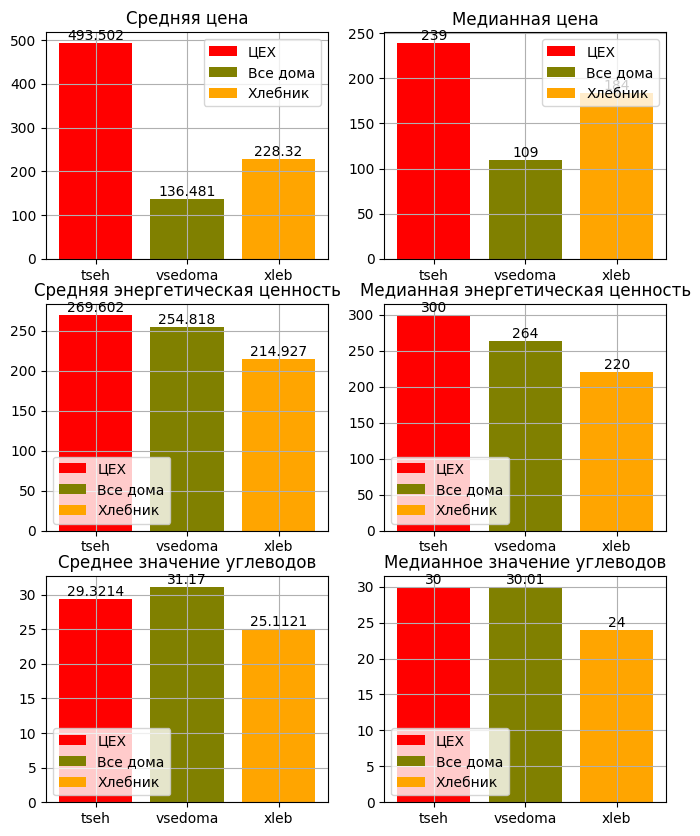

In [ ]:
fig, axes = plt.subplots(3, 2, figsize=(8, 10))
axes = axes.flatten()
mean_value = df.groupby('Bakery').mean(numeric_only=True)
median_values = df.groupby('Bakery').median(numeric_only=True)
bakeries = mean_value.index.to_list()
def plot_bars(ax, x_values, y_values, labels, colors, title):
  bars = []
  for i in range(len(x_values)):
    bar = ax.bar(x_values[i], y_values[i], label=labels[i], color=colors[i])
    ax.bar_label(bar, padding=0)
  ax.grid()
  ax.set_title(title)
  ax.legend()

labels = ["ЦЕХ", "Все дома", "Хлебник"]
colors = ["red", "olive", "orange"]
plot_bars(axes[0], bakeries, mean_value["price"], labels, colors, "Средняя цена")
plot_bars(axes[1], bakeries, median_values["price"], labels, colors, "Медианная цена")
plot_bars(axes[2], bakeries, mean_value["energy_value"], labels, colors, "Средняя энергетическая ценность")
plot_bars(axes[3], bakeries, median_values["energy_value"], labels, colors, "Медианная энергетическая ценность")
plot_bars(axes[4], bakeries, mean_value["carbohydrates"], labels, colors, "Среднее значение углеводов")
plot_bars(axes[5], bakeries, median_values["carbohydrates"], labels, colors, "Медианное значение углеводов")

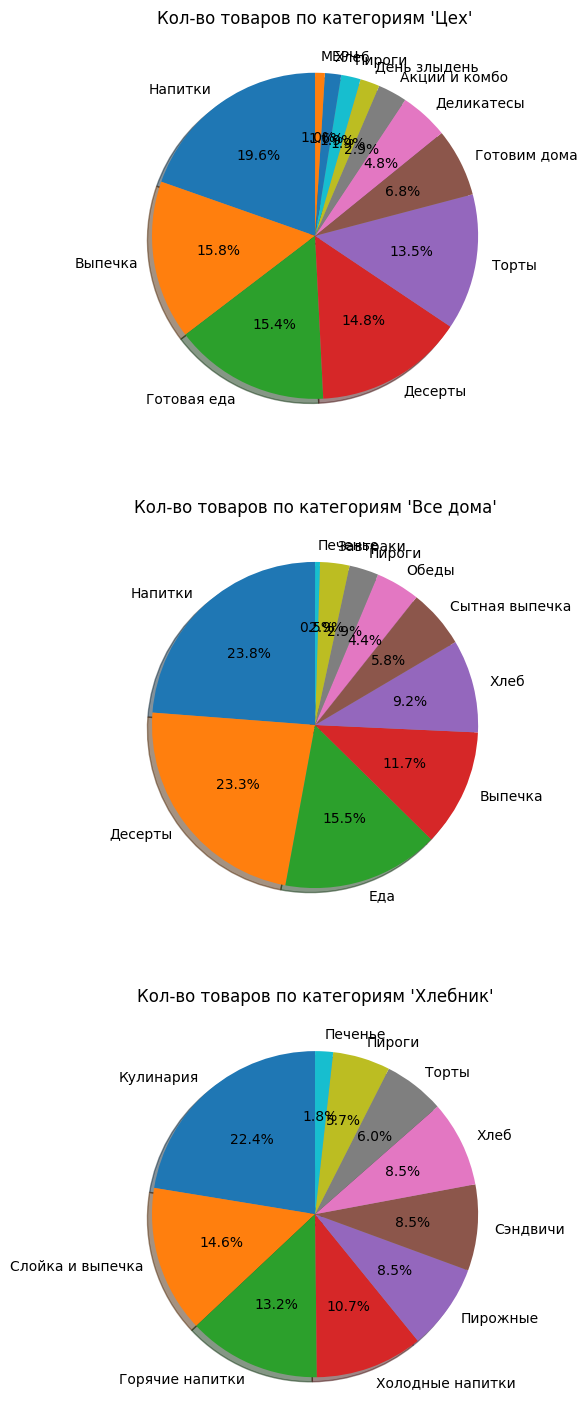

In [ ]:
fig, axes = plt.subplots(3, 1, figsize=(15, 18))
axes = axes.flatten()
def plot_pie(ax, data, title):
  counts = data.value_counts()
  ax.pie(
      counts,
      labels=counts.index,
      autopct='%1.1f%%',
      startangle=90,
      shadow=True
  )
  ax.set_title(title)
plot_pie(axes[0], tseh['category'], "Кол-во товаров по категориям 'Цех'")
plot_pie(axes[1], vsedoma['category'], "Кол-во товаров по категориям 'Все дома'")
plot_pie(axes[2], xleb['category'], "Кол-во товаров по категориям 'Хлебник'")

{'whiskers': [<matplotlib.lines.Line2D at 0x7f2ed8bc22d0>,
 'caps': [<matplotlib.lines.Line2D at 0x7f2ed8ce3bf0>,
 'boxes': [<matplotlib.lines.Line2D at 0x7f2ed8ce1b20>],
 'medians': [<matplotlib.lines.Line2D at 0x7f2ed8ce29f0>],
 'fliers': [<matplotlib.lines.Line2D at 0x7f2ed8ce2150>],
 'means': []}

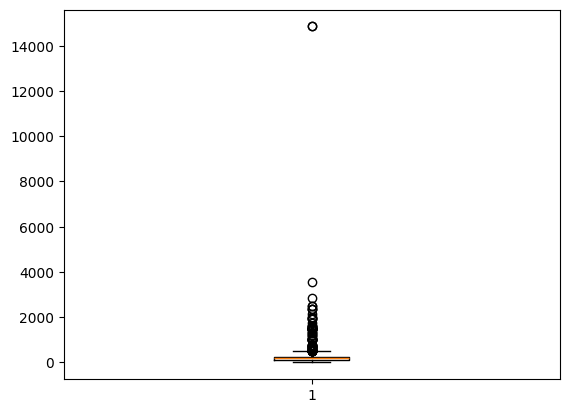

In [ ]:
plt.boxplot(df['price'])

In [ ]:
df[df['price'] > 2000]

,Unnamed: 0,category,subcategory,name,price,proteins,fats,carbohydrates,energy_value,weight,ingredients,Bakery
251,251,Торты,На заказ,Корпоративный торт Чёрный лес,14850.0,3.17,14.68,33.52,278.90,7700,"Сахар, меланж яичный, вишня, сыр мягкий (молок...",tseh
252,252,Торты,На заказ,Корпоративный торт Сметанник,14850.0,4.23,14.64,41.47,314.60,7500,"Сметана 20%, сахар, мука пшеничная в/с, черная...",tseh
253,253,Торты,На заказ,"Сметанник с чёрной смородиной, розовый",3550.0,3.00,20.30,26.90,302.90,1800,"Сметана, сахар, мука пшеничная хлебопекарная в...",tseh
254,254,Торты,На заказ,Шоколадно-кофейный торт,2490.0,4.50,17.30,33.60,308.20,1600,"Сахар, крем на растительных маслах (вода питье...",tseh
260,260,Торты,На заказ,Торт Чёрный лес,2850.0,3.60,17.40,38.20,323.80,1650,"Крем на растительных маслах (вода питьевая, жи...",tseh
262,262,Торты,На заказ,Морковный торт с украшением,2360.0,3.90,20.30,36.70,343.80,1450,"Сахар, морковь, мука пшеничная в/с, масло раст...",tseh
264,264,Торты,На заказ,Торт Мята-миндаль,2490.0,4.60,24.10,27.20,344.40,1360,"Сливки 35% (нормализованные сливки, стабилизат...",tseh
267,267,Торты,На заказ,Шоколадный медовик,2380.0,5.10,21.90,53.13,430.16,1890,"Сметана, сахар, мука пшеничная хлебопекарная в...",tseh
275,275,Торты,На заказ,Маковый торт с малиной,2350.0,3.60,21.10,37.50,354.90,1320,"Крем на растительных маслах (вода, гидрогенизи...",tseh
692,175,Пироги,NaN,Пирог с лососем,2164.0,11.00,13.00,20.00,240.00,NaN,": мука пшеничная хлебопекарная высшего сорта, ...",xleb


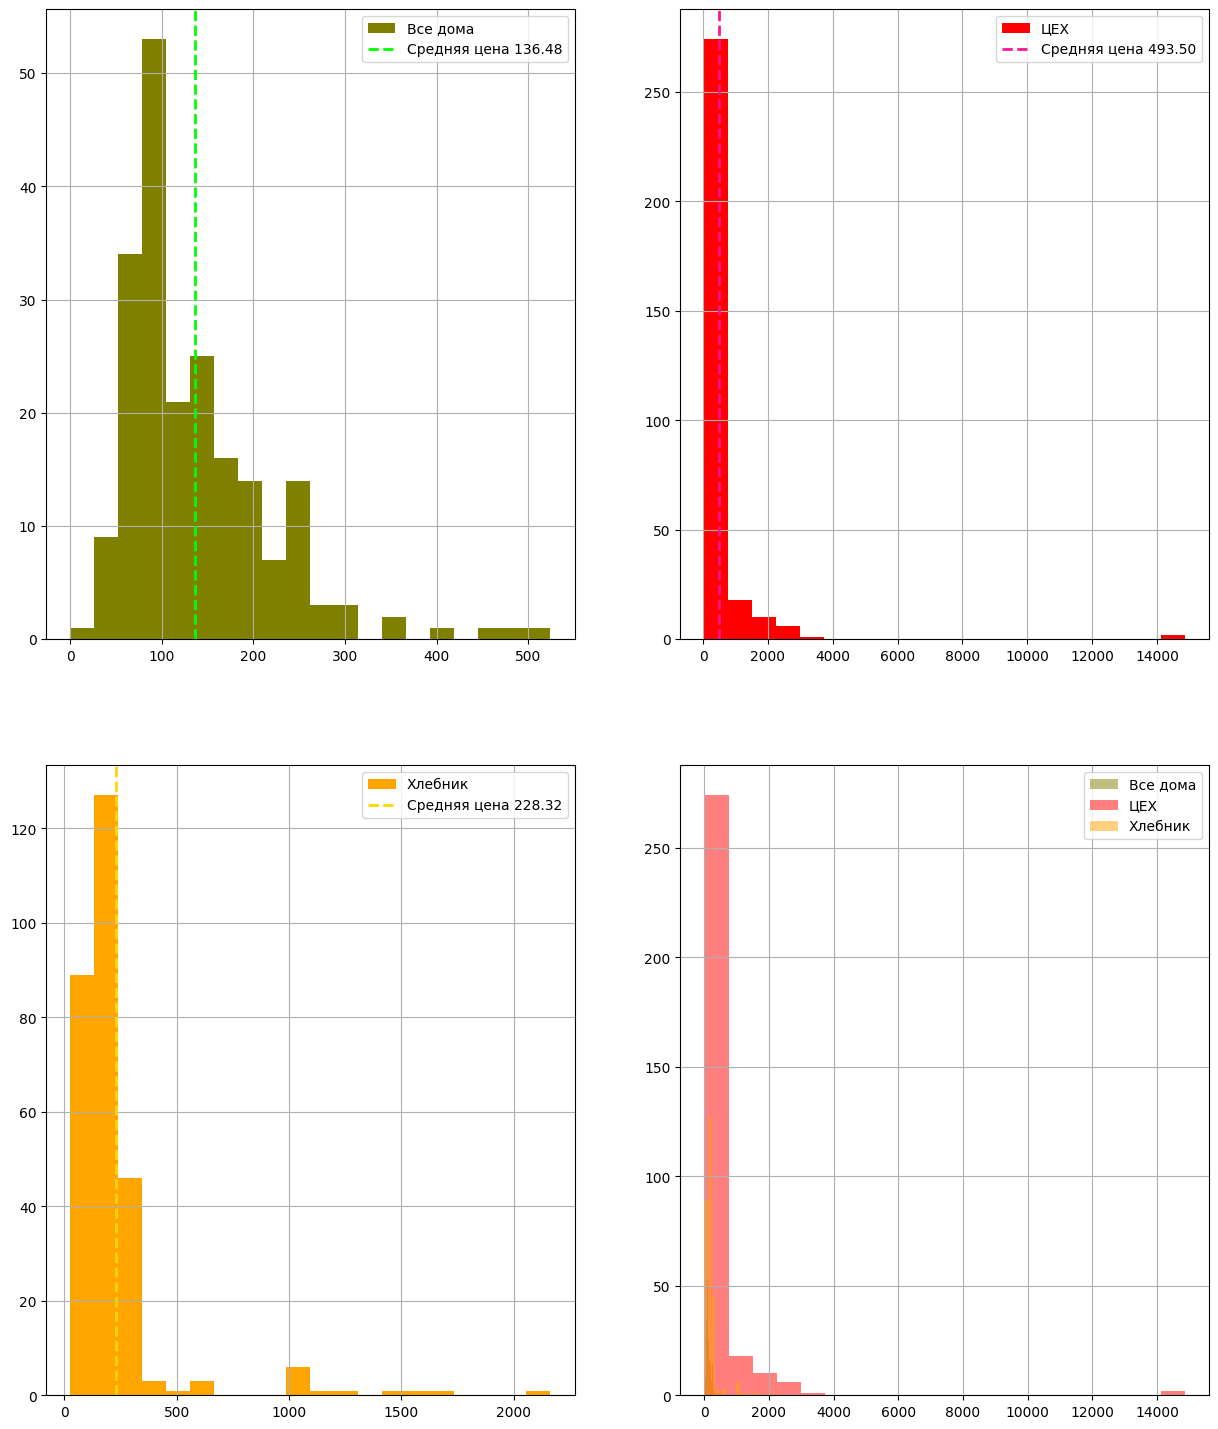

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(15, 18))
axes = axes.flatten()
tseh_df = df[df['Bakery'] == 'tseh']
vsedoma_df = df[df['Bakery'] == 'vsedoma']
xleb_df = df[df['Bakery'] == 'xleb']
axes[0].hist(vsedoma_df['price'], color="olive", bins=20, label=labels[1])
axes[0].grid()
axes[0].axvline(vsedoma_df['price'].mean(), color='lime', linestyle='--', linewidth=2, label=f'Средняя цена {vsedoma_df['price'].mean():.2f}')
axes[0].legend()
axes[1].hist(tseh_df['price'], color="red" , bins=20, label=labels[0])
axes[1].grid()
axes[1].axvline(tseh_df['price'].mean(), color='deeppink', linestyle='--', linewidth=2, label=f'Средняя цена {tseh_df['price'].mean():.2f}')
axes[1].legend()
# axes[1].set_xlim((0, 1000))
axes[2].hist(xleb_df['price'], color="orange", bins=20, label=labels[2])
axes[2].grid()
axes[2].axvline(xleb_df['price'].mean(), color='gold', linestyle='--', linewidth=2, label=f'Средняя цена {xleb_df['price'].mean():.2f}')
axes[2].legend()
axes[3].hist(vsedoma_df['price'], color="olive", bins=20,label=labels[1], alpha=0.5)
axes[3].hist(tseh_df['price'], color="red", bins=20, label=labels[0], alpha=0.5)
axes[3].hist(xleb_df['price'], color="orange", bins=20, label=labels[2], alpha=0.5)
axes[3].grid()
axes[3].legend()


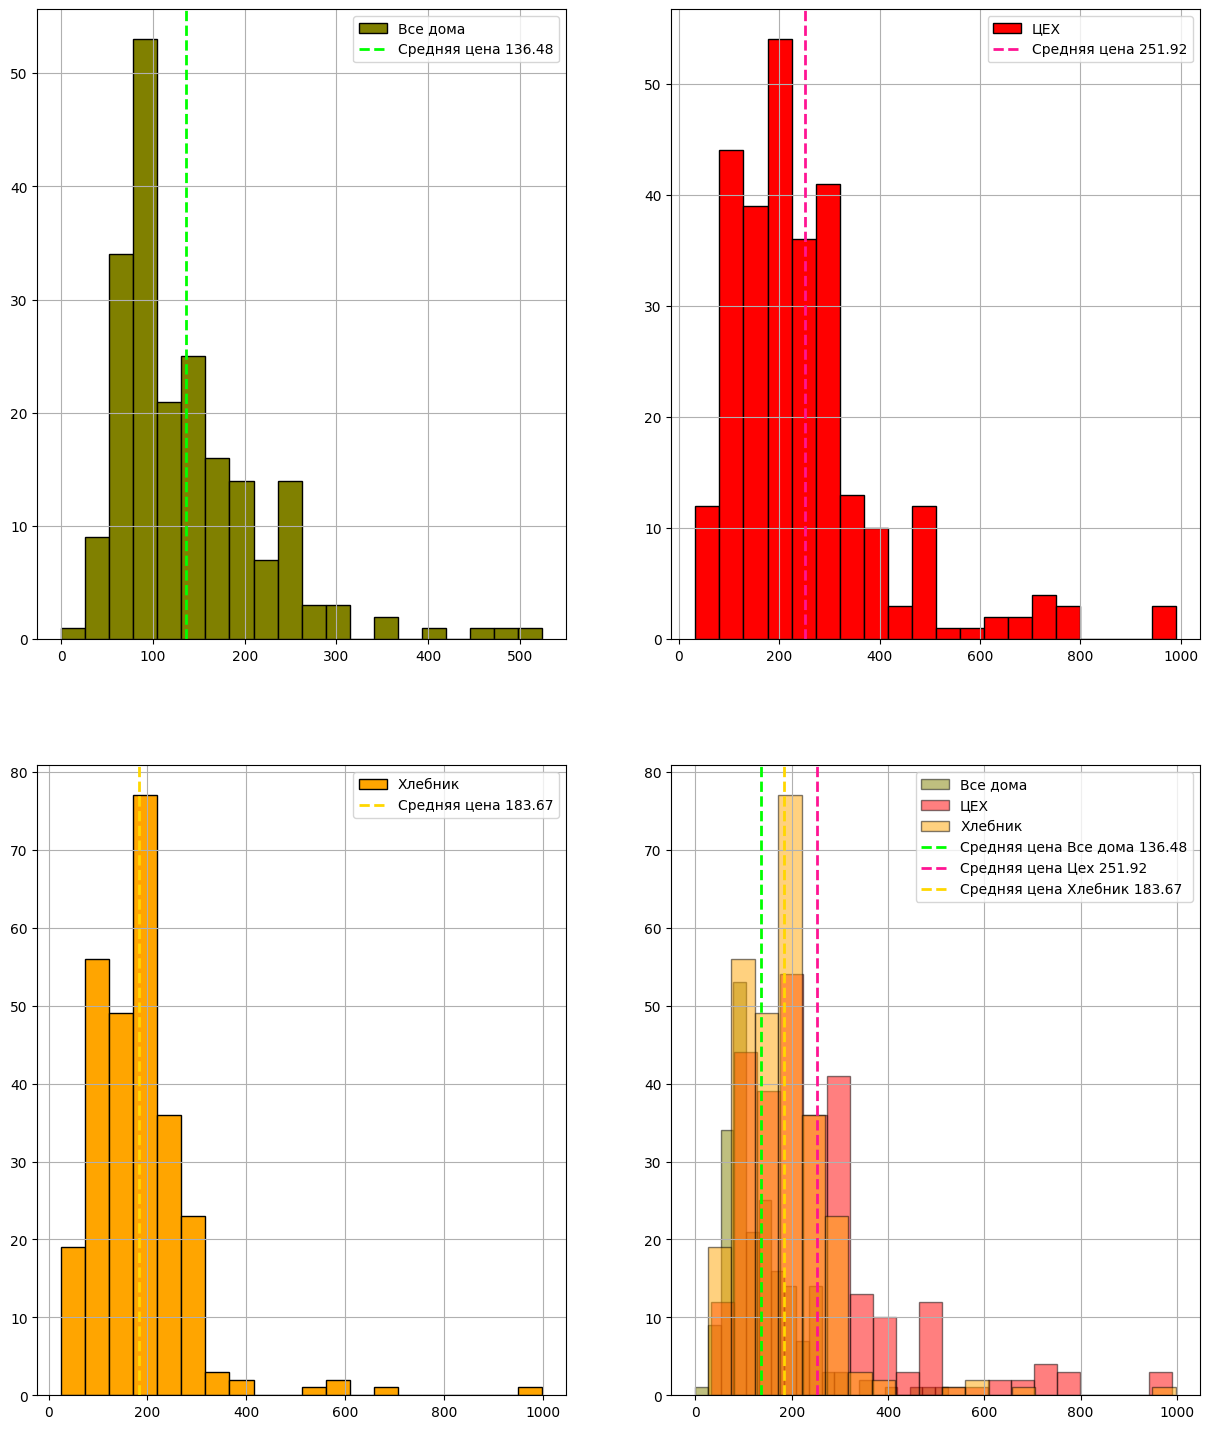

In [ ]:
low_price_df = df[df['price'] < 1000]
fig, axes = plt.subplots(2, 2, figsize=(15, 18))
axes = axes.flatten()
tseh_df = low_price_df[low_price_df['Bakery'] == 'tseh']
vsedoma_df = low_price_df[low_price_df['Bakery'] == 'vsedoma']
xleb_df = low_price_df[low_price_df['Bakery'] == 'xleb']
axes[0].hist(vsedoma_df['price'], color="olive", bins=20, label=labels[1],edgecolor='black')
axes[0].grid()
axes[0].axvline(vsedoma_df['price'].mean(), color='lime', linestyle='--', linewidth=2, label=f'Средняя цена {vsedoma_df['price'].mean():.2f}')
axes[0].legend()
axes[1].hist(tseh_df['price'], color="red" , bins=20, label=labels[0],edgecolor='black')
axes[1].grid()
axes[1].axvline(tseh_df['price'].mean(), color='deeppink', linestyle='--', linewidth=2, label=f'Средняя цена {tseh_df['price'].mean():.2f}')
axes[1].legend()
# axes[1].set_xlim((0, 1000))
axes[2].hist(xleb_df['price'], color="orange", bins=20, label=labels[2],edgecolor='black')
axes[2].grid()
axes[2].axvline(xleb_df['price'].mean(), color='gold', linestyle='--', linewidth=2, label=f'Средняя цена {xleb_df['price'].mean():.2f}')
axes[2].legend()
axes[3].hist(vsedoma_df['price'], color="olive", bins=20,label=labels[1], alpha=0.5,edgecolor='black')
axes[3].hist(tseh_df['price'], color="red", bins=20, label=labels[0], alpha=0.5,edgecolor='black')
axes[3].hist(xleb_df['price'], color="orange", bins=20, label=labels[2], alpha=0.5,edgecolor='black')
axes[3].axvline(vsedoma_df['price'].mean(), color='lime', linestyle='--', linewidth=2, label=f'Средняя цена Все дома {vsedoma_df['price'].mean():.2f}')
axes[3].axvline(tseh_df['price'].mean(), color='deeppink', linestyle='--', linewidth=2, label=f'Средняя цена Цех {tseh_df['price'].mean():.2f}')
axes[3].axvline(xleb_df['price'].mean(), color='gold', linestyle='--', linewidth=2, label=f'Средняя цена Хлебник {xleb_df['price'].mean():.2f}')

axes[3].grid()
axes[3].legend()
